### 1. Chuẩn bị dữ liệu cho trực quan hóa dữ liệu

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu rượu đỏ (winequality-red.csv tải từ Kaggle)
wine_data = pd.read_csv("winequality-red.csv")
# Lấy ra các cột quan trọng để phân tích 
wine_data = wine_data[['quality', 'alcohol', 'pH', 'residual sugar', 'volatile acidity']]
# Tạo thêm biến mới: tỉ lệ alcohol / acidity
wine_data['alc_acid_ratio'] = wine_data['alcohol'] / wine_data['volatile acidity']
# Sắp xếp dữ liệu theo độ cồn (alcohol) giảm dần
wine_sorted = wine_data.sort_values('alcohol', ascending=False)
wine_sorted.head()


,quality,alcohol,pH,residual sugar,volatile acidity,alc_acid_ratio
652,5,14.9,2.98,7.5,0.36,41.388889
1269,8,14.0,3.50,1.8,0.49,28.571429
588,8,14.0,3.72,2.0,0.42,33.333333
467,6,14.0,3.32,2.6,0.46,30.434783
1270,6,14.0,3.70,1.6,0.38,36.842105


### Ý nghĩa của biến
| Tên biến                        | Ý nghĩa                                                               | Đơn vị/Thang đo                 | Ghi chú                                                                                   |
| ------------------------------- | --------------------------------------------------------------------- | ------------------------------- | ----------------------------------------------------------------------------------------- |
| **quality**                     | Điểm số chất lượng rượu, do chuyên gia thử nếm đánh giá               | Thang điểm 0–10 (số nguyên)     | Đây là biến mục tiêu để phân loại hoặc dự đoán                                            |
| **alcohol**                     | Nồng độ cồn trong rượu                                                | % thể tích (% vol)              | Thường rượu có nồng độ cồn cao được đánh giá chất lượng cao hơn                           |
| **pH**                          | Độ pH – đo độ axit hay bazơ của rượu                                  | Giá trị khoảng 2.5 – 4.5        | pH thấp = rượu chua/axit cao; pH cao = ít axit                                            |
| **residual sugar**              | Lượng đường còn lại sau quá trình lên men                             | g/L                             | Ảnh hưởng đến độ ngọt, cân bằng vị của rượu                                               |
| **volatile acidity**            | Hàm lượng axit bay hơi (chủ yếu là axit axetic)                       | g/L                             | Nồng độ cao → dễ gây mùi giấm, làm giảm chất lượng                                        |
| **alc_acid_ratio** *(biến mới)* | Tỷ lệ giữa nồng độ cồn và axit bay hơi (`alcohol / volatile acidity`) | Chỉ số tương đối (không đơn vị) | Phản ánh mức cân bằng giữa độ cồn và độ axit; tỷ lệ cao thường gắn với rượu mạnh, ít axit |


### 2. Trực quan hóa dữ liệu với thư viện Matplotlib

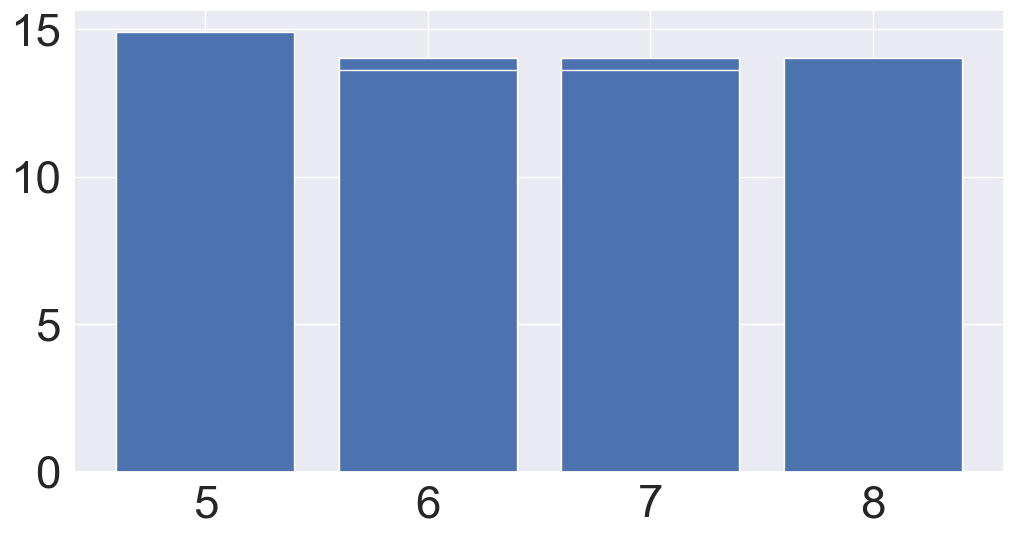

In [25]:
# case1: basic
plt.figure(figsize=(12,6))
x = wine_sorted['quality'][0:10]
y = wine_sorted['alcohol'][0:10]
plt.bar(x, y)
plt.show()

### Kết luận
Biểu đồ cột cơ bản hiển thị 10 mẫu rượu vang đỏ có nồng độ cồn (alcohol) cao nhất, với trục hoành là mức chất lượng (quality) và trục tung là độ cồn.

- Qua biểu đồ, có thể thấy những mẫu rượu ở mức chất lượng 6 và 7 thường xuất hiện trong nhóm có nồng độ cồn cao.

- Điều này gợi ý rằng độ cồn có thể là một yếu tố quan trọng ảnh hưởng đến đánh giá chất lượng rượu.

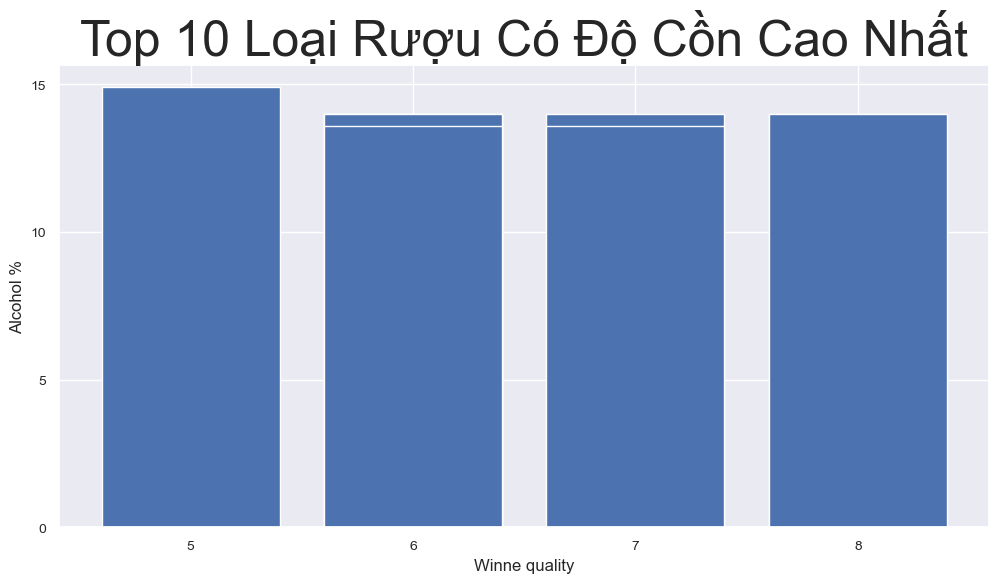

In [26]:
#case 2: advanced 1
plt.figure(figsize=(12,6))
x = wine_sorted['quality'][0:10]
y = wine_sorted['alcohol'][0:10]
plt.bar(x,y)
plt.title("Top 10 Loại Rượu Có Độ Cồn Cao Nhất")
plt.xlabel('Winne quality', fontsize = 12)
plt.xticks(fontsize = 10)
plt.ylabel("Alcohol %", fontsize = 12)
plt.yticks(fontsize = 10)
plt.show()

### Kết luận
Ở biểu đồ nâng cao, ta bổ sung tiêu đề, nhãn trục và cỡ chữ, giúp trực quan hóa dễ đọc và dễ hiểu hơn.

- Có thể nhận thấy rõ rằng các mẫu rượu có độ cồn từ khoảng 13% trở lên hầu hết thuộc nhóm chất lượng trung bình khá (6) đến cao (7–8).

- So với Case 1, biểu đồ này mang tính trình bày khoa học và trực quan hơn, phù hợp cho báo cáo nghiên cứu.

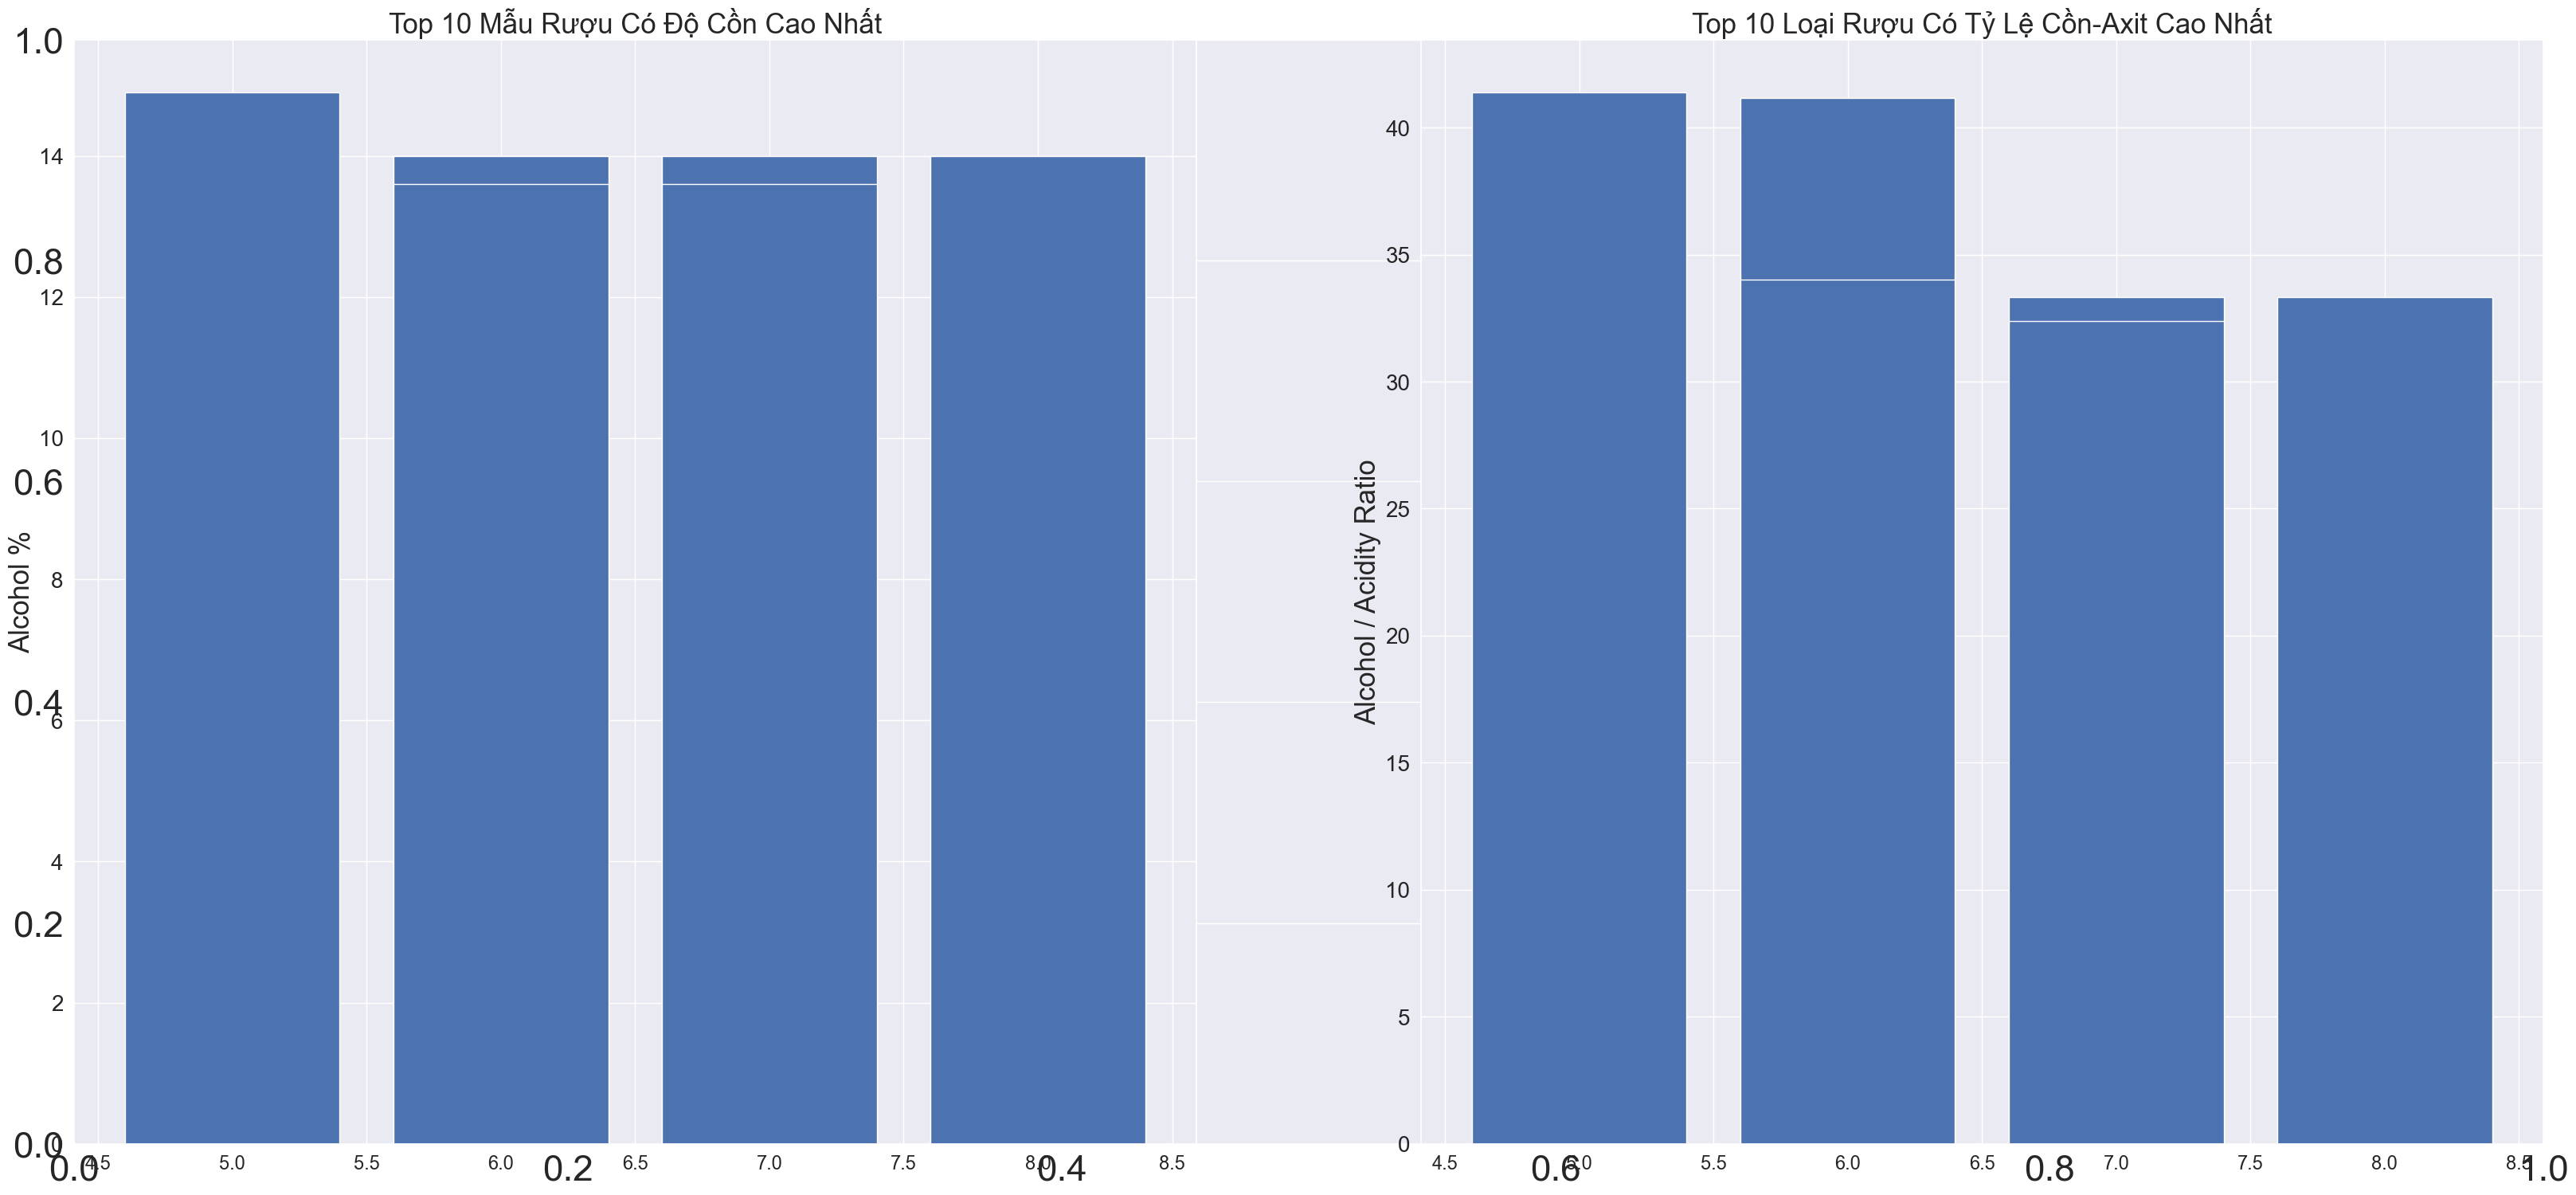

In [24]:
#case 3: advanced 2
fig, ax = plt.subplots(figsize=(40,18))
x = wine_sorted['quality'][0:10]
y = wine_sorted['alcohol'][0:10]
y1 = wine_sorted['alc_acid_ratio'][0:10]

plt.subplot(1,2,1)
plt.bar(x,y)
plt.xticks(fontsize = 17)
plt.ylabel('Alcohol %', fontsize = 25)
plt.yticks(fontsize = 20)
plt.title("Top 10 Mẫu Rượu Có Độ Cồn Cao Nhất", fontsize = 25)

plt.subplot(1,2,2)
plt.bar(x,y1)
plt.xticks(fontsize=17)
plt.ylabel('Alcohol / Acidity Ratio', fontsize=25)
plt.yticks(fontsize=20)
plt.title('Top 10 Loại Rượu Có Tỷ Lệ Cồn-Axit Cao Nhất', fontsize=25)
plt.show()


### Kết luận
Biểu đồ này hiển thị song song hai khía cạnh:

1. Độ cồn (Alcohol)

2. Tỷ lệ độ cồn trên độ chua bay hơi (Alcohol / Volatile acidity)

- Ở biểu đồ trái, ta vẫn thấy xu hướng quen thuộc: những rượu có độ cồn cao thường đi kèm chất lượng cao.

- Ở biểu đồ phải, khi so sánh theo tỷ lệ alc_acid_ratio, ta nhận ra rằng rượu có tỷ lệ cao (nghĩa là nhiều cồn, ít độ chua bay hơi) thì chất lượng cũng thường cao hơn.

- Như vậy, không chỉ bản thân độ cồn, mà sự cân bằng giữa độ cồn và độ chua bay hơi cũng đóng vai trò quan trọng trong việc quyết định chất lượng rượu.

### 3. Trực quan hoá dữ liệu với thư viện   Seaborn

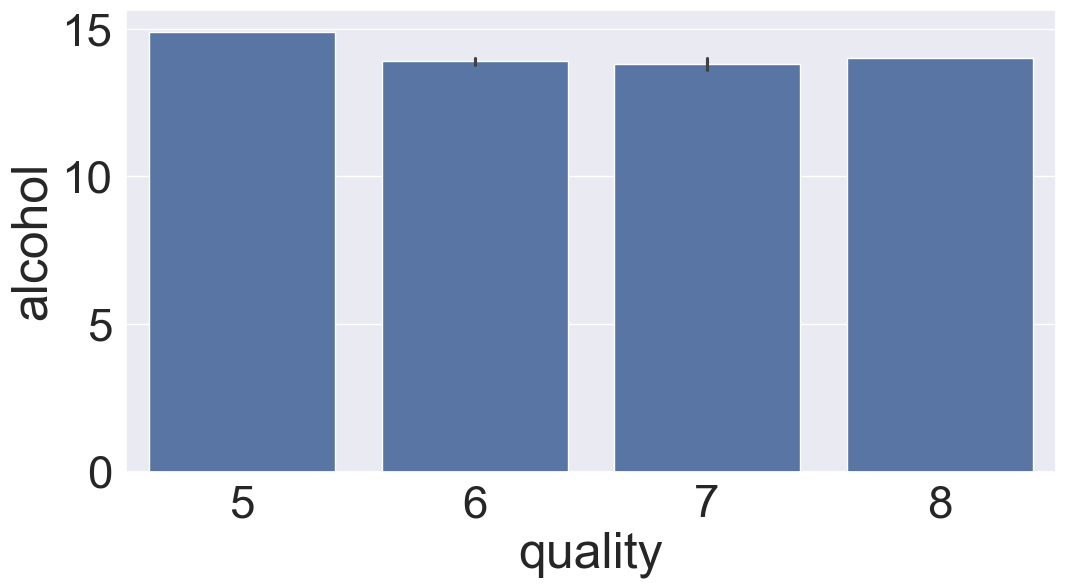

In [22]:
#case 1: basic
plt.figure(figsize= (12,6))
data = wine_sorted[0:10]
sns.barplot(data = data, x='quality', y='alcohol')
plt.show()

### Kết luận
Biểu đồ cột sử dụng Seaborn cho thấy 10 mẫu rượu vang đỏ có độ cồn cao nhất.

- Mặc dù kết quả tương tự Matplotlib Case 1, nhưng biểu đồ đẹp mắt hơn nhờ thiết kế mặc định của Seaborn.

- Sự phân bố giá trị dễ nhận biết, giúp người xem nhanh chóng nắm bắt xu hướng

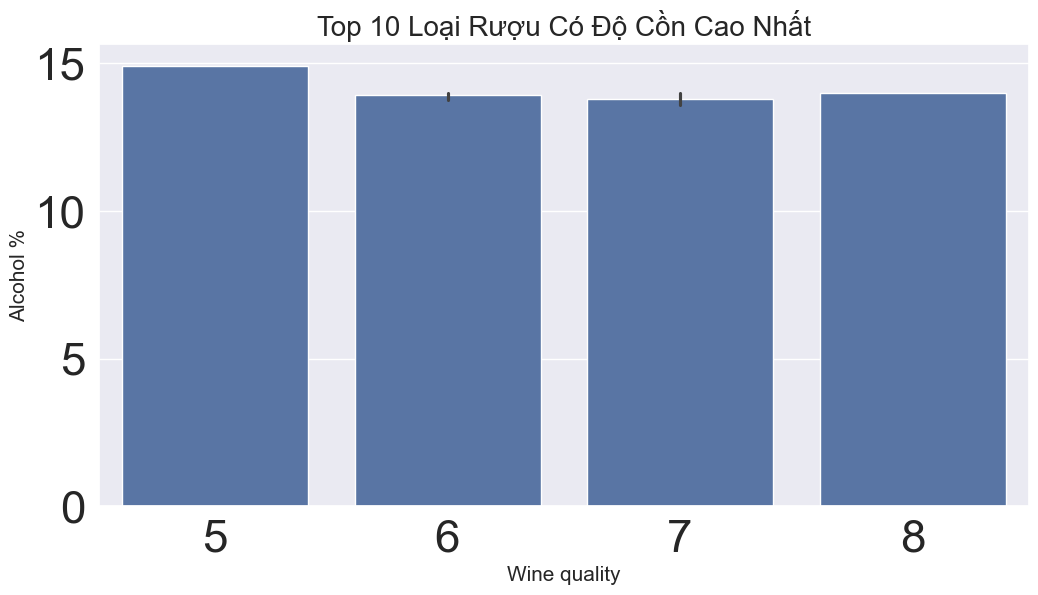

In [19]:
#case 2: advanced 1
plt.figure(figsize= (12,6))
data = wine_sorted[0:10]
ax = sns.barplot(data=data, x='quality', y='alcohol')
ax.set_xlabel('Wine quality', fontsize = 15)
ax.set_ylabel('Alcohol %', fontsize = 15)
ax.set_title('Top 10 Loại Rượu Có Độ Cồn Cao Nhất', fontsize = 20)
plt.show()

### Kết luận
Ở biểu đồ này, nhãn trục, tiêu đề và phông chữ được thiết lập rõ ràng, giúp biểu đồ mang tính chuyên nghiệp.

- Người xem dễ dàng thấy rằng chất lượng từ mức 6 đến 7 chiếm đa số trong nhóm rượu có độ cồn cao.

- Đây là dấu hiệu củng cố giả thuyết rằng nồng độ cồn có ảnh hưởng tích cực đến chất lượng rượu.

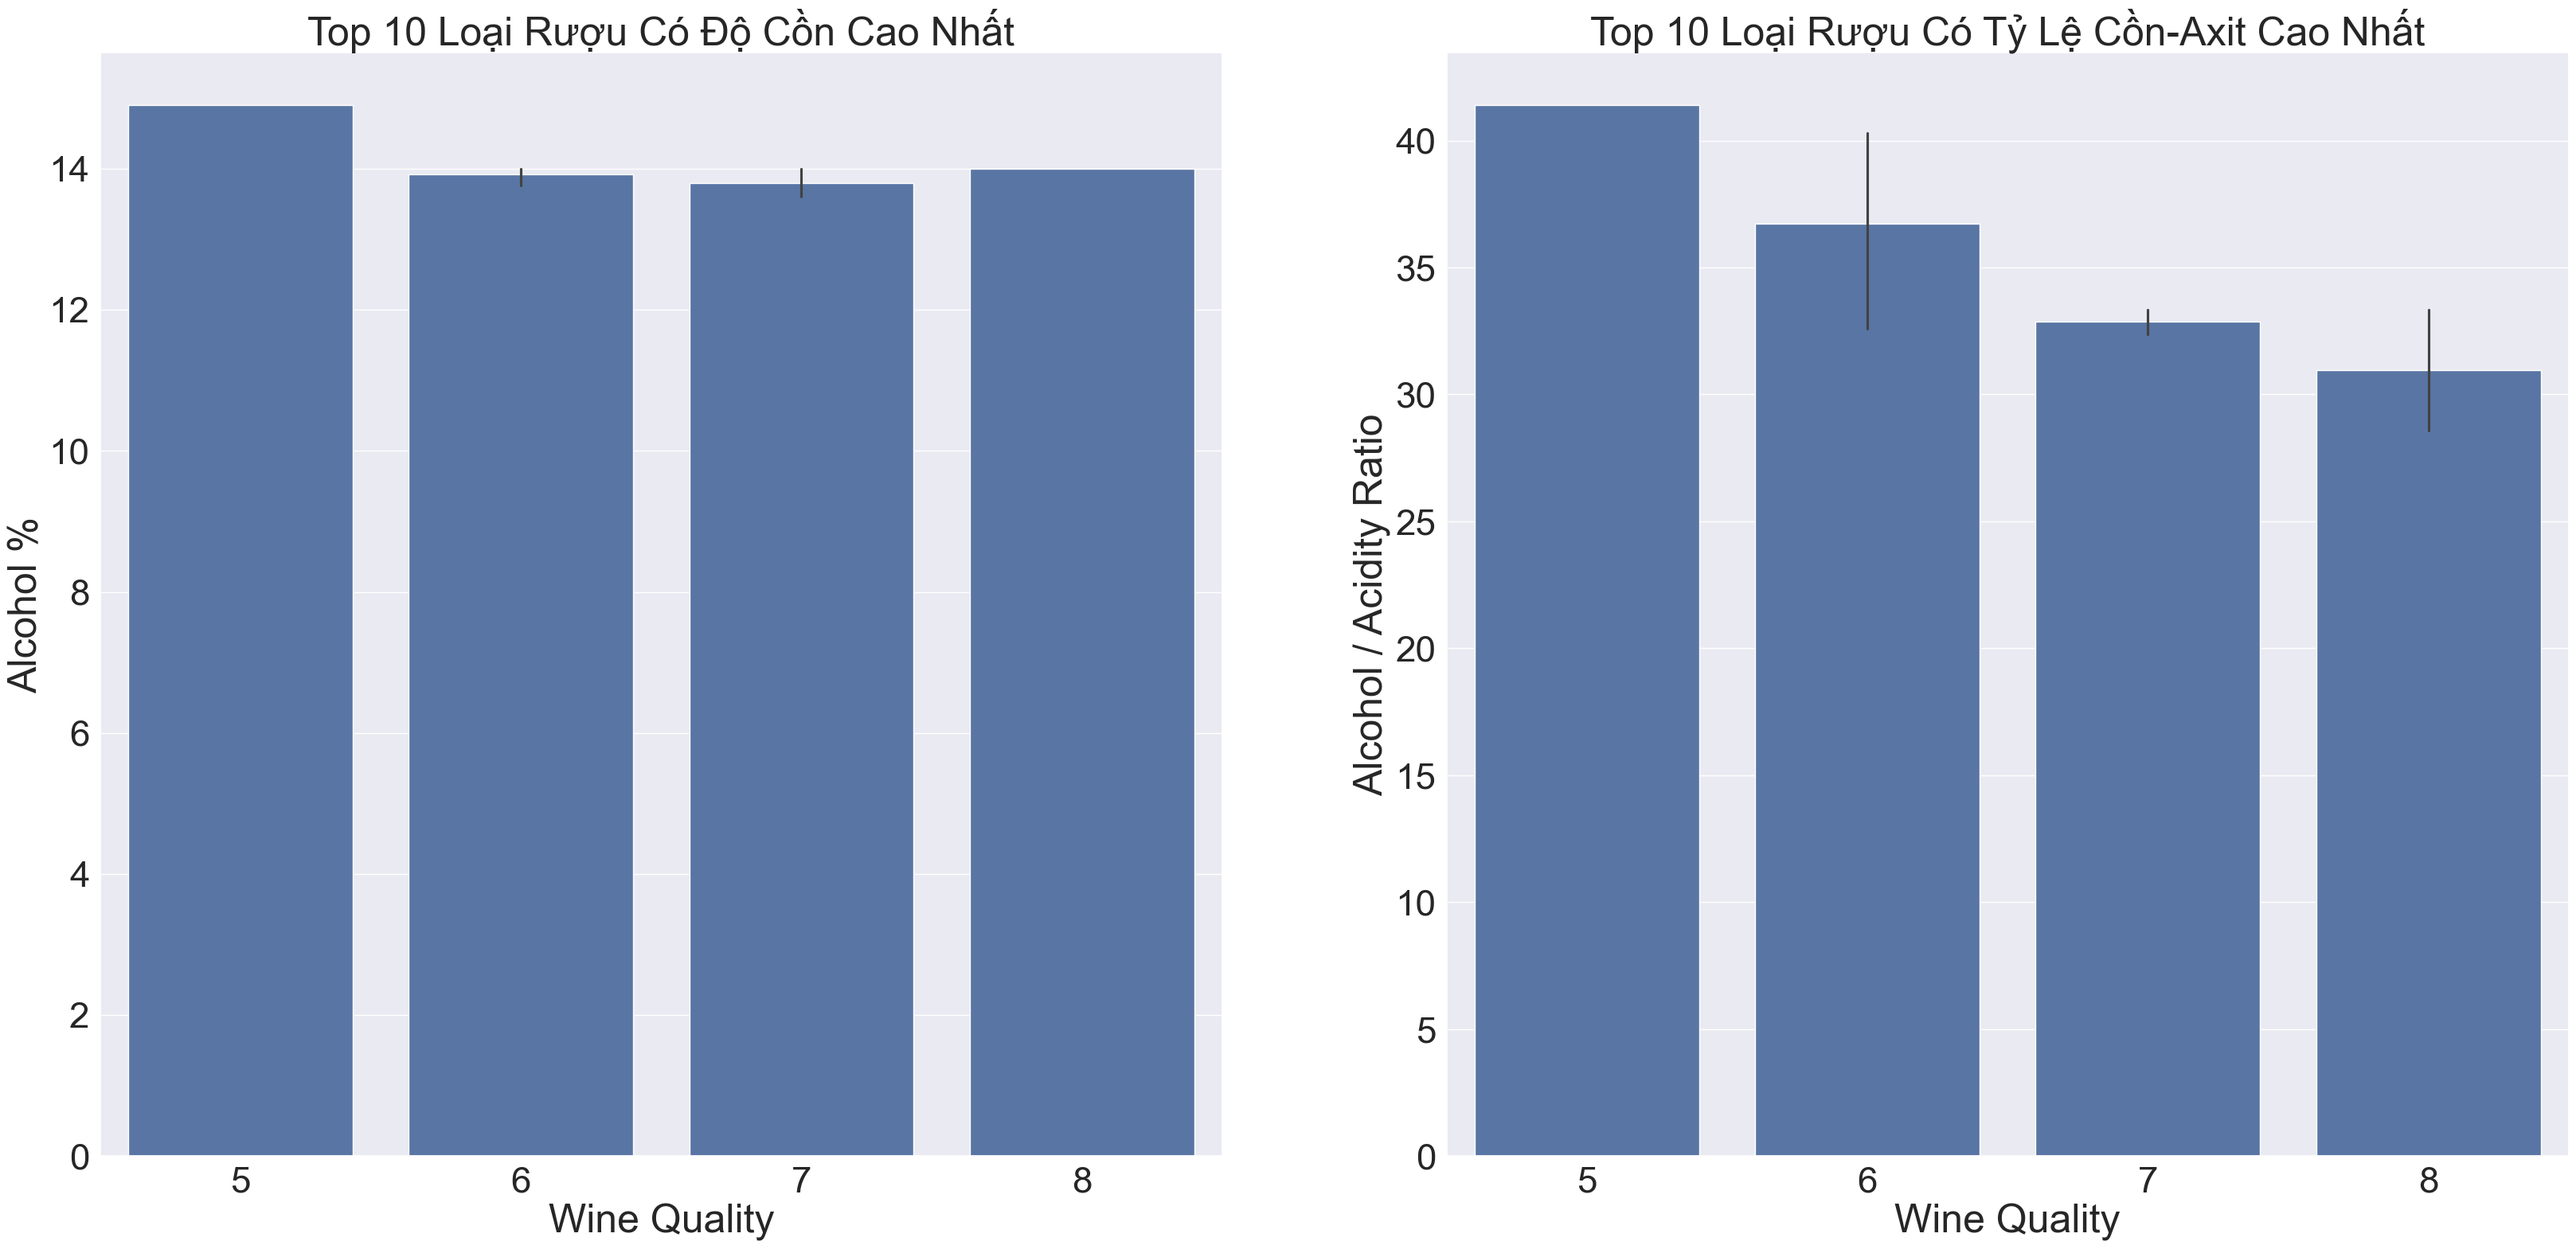

In [18]:
#case 3: Multiple Perspectives
fig, ax = plt.subplots(1, 2, figsize=(40,18))
data = wine_sorted[0:10]
sns.set(font_scale=3)

ax1 = sns.barplot(data=data, x='quality', y='alcohol', ax=ax[0])
ax1.set_xlabel('Wine Quality')
ax1.set_ylabel('Alcohol %')
ax1.set_title('Top 10 Loại Rượu Có Độ Cồn Cao Nhất')

ax2 = sns.barplot(data=data, x='quality', y='alc_acid_ratio', ax=ax[1])
ax2.set_xlabel('Wine Quality')
ax2.set_ylabel('Alcohol / Acidity Ratio')
ax2.set_title('Top 10 Loại Rượu Có Tỷ Lệ Cồn-Axit Cao Nhất')
plt.show()


### Kết luận
Ở đây ta quan sát cùng lúc hai biến:

1. Alcohol (độ cồn)

2. Alcohol / Volatile acidity (tỷ lệ độ cồn trên độ chua bay hơi)

- Biểu đồ bên trái khẳng định rằng độ cồn cao thường gắn với chất lượng cao.

- Biểu đồ bên phải bổ sung thêm một góc nhìn: những rượu có tỷ lệ cồn/chua bay hơi cao thường đạt chất lượng tốt hơn.

- Như vậy, việc trực quan hóa đa chiều giúp ta hiểu rõ hơn mối quan hệ giữa đặc tính hóa học và đánh giá cảm quan về chất lượng rượu.

# 4. Kết luận từ trục quan hoá
- Độ cồn (alcohol) là một trong những biến quan trọng nhất, có mối quan hệ dương với chất lượng rượu vang đỏ.

- Độ chua bay hơi (volatile acidity) có mối quan hệ âm với chất lượng, nghĩa là càng nhiều độ chua bay hơi thì chất lượng rượu càng giảm.

- Tỷ lệ giữa hai yếu tố này (alcohol / volatile acidity) thể hiện sự cân bằng, và những rượu có tỷ lệ cao thường được đánh giá chất lượng tốt hơn.